# Quickstart

This notebook packs spheres in a periodic box, inspects the result and saves it.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/computational-chemical-engineering/spheropack/blob/main/docs/notebooks/01_quickstart.ipynb) [![Download notebook](https://img.shields.io/badge/download-notebook-orange?logo=jupyter)](https://computational-chemical-engineering.github.io/spheropack/notebooks/01_quickstart.ipynb)

In [ ]:
# Install spheropack when it is not available (for example on Google Colab).
import importlib.util

if importlib.util.find_spec("spheropack") is None:
    %pip install -q spheropack

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import spheropack as sp
from spheropack.plotting import plot_disks, plot_section

## A packing at a given density

`pack` places `n` spheres at random as points, lets them move, collide and grow, and stops when the volume fraction reaches `density`. Without a container it uses the periodic unit cube. Fix `seed` to make the result reproducible.

In [2]:
p = sp.pack(n=2000, density=0.6, seed=1)
p

Packing(n=2000, dim=3, density=0.6, status='target', reduced_pressure=40, n_collisions=543484, seed=1)

The result holds the centres, radii and run statistics. `status` tells why the run stopped; `"target_reached"` means the requested density was reached.

In [3]:
print(p.positions.shape, p.radii[:3])
print(f"density {p.density:.4f}, {p.n_collisions} collisions in {p.wall_time:.2f} s")

(2000, 3) [0.04152831 0.04152831 0.04152831]
density 0.6000, 543484 collisions in 1.86 s


A cross-section through the middle of the box shows each sphere cut by the plane as a disk.

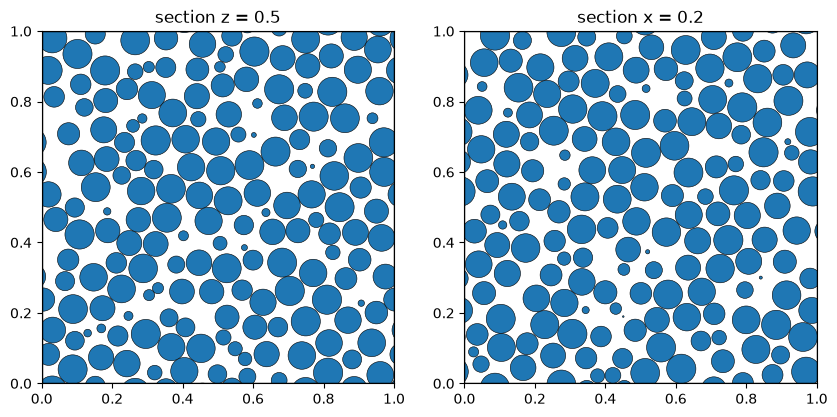

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_section(p, axis=2, ax=axes[0])
axes[0].set_title("section z = 0.5")
plot_section(p, axis=0, position=0.2, ax=axes[1])
axes[1].set_title("section x = 0.2");

## Absolute radii, polydispersity and 2D

Without `density` the spheres grow until they have the radii you give. With `density` only the ratios of the radii matter. Here a bidisperse mixture (size ratio 1.4) in 2D:

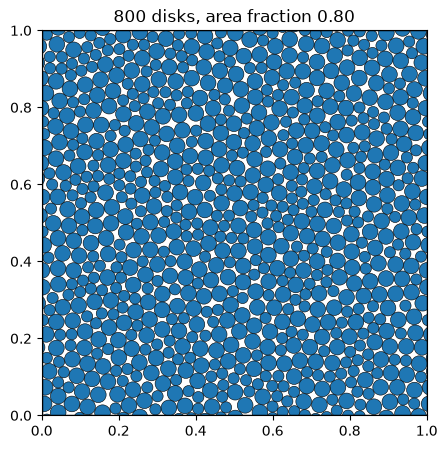

In [5]:
rng = np.random.default_rng(0)
radii = np.where(rng.random(800) < 0.5, 1.0, 1.4)
q = sp.pack(radii=radii, density=0.8, container=sp.PeriodicBox(1.0, dim=2), seed=2)
ax = plot_disks(q)
ax.set_title(f"{q.n} disks, area fraction {q.density:.2f}");

## Walls

A `Box` can have flat walls along any axis. This slab is periodic in x and y and bounded by walls in z; the wall induces layering, visible in the density profile (see the structure analysis notebook).

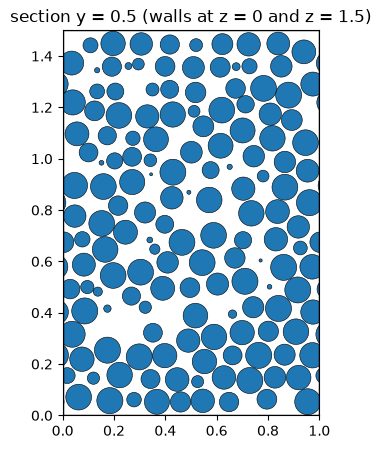

In [6]:
slab = sp.Box([1.0, 1.0, 1.5], periodic=[True, True, False])
s = sp.pack(n=1500, density=0.55, container=slab, seed=3)
ax = plot_section(s, axis=1)
ax.set_title("section y = 0.5 (walls at z = 0 and z = 1.5)");

## Saving

`to_csv` writes `x,y,z,r` per sphere. `legacy_order=True` gives the `z,x,y,r` format of the legacy command-line tools. For visualisation of a periodic box, `periodic_images()` adds the copies of spheres that cut the faces.

In [7]:
p.to_csv("packing.csv")
print(open("packing.csv").read()[:200])
print(p.n, "->", p.periodic_images().n, "spheres with periodic images")

x,y,z,r
0.66164875072970064,0.85978568316731141,0.29863649205077775,0.041528305920770746
0.99169993676951873,0.3734523546420539,0.72006479215377095,0.041528305920770746
0.36266396322224626,0.980688632
2000 -> 2557 spheres with periodic images
